# Trabajo Práctico 2

## Modelo predictivo de lluvia en Australia

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Integrantes:**
| Nombre | Legajo |
|----------|-------|
| Chiappe, Maximiliano | C-7542/6 |
| Lenarduzzi, Juan | L-3398/7 |
---



## Configuración del Entorno

In [3]:
# ── Librerías generales ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn: preprocesamiento ───────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-learn: regresión logística ────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

---

## Carga e Inspección del Dataset

In [4]:
df = pd.read_csv('weatherAUS_2026C1.csv')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(5)

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 82.42 MB



,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  object 
 2   Location          145412 non-null  object 
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  object 
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  object 
 11  WindDir3pm        141186 non-null  object 
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       13

---
## Análisis Descriptivo

---
### Limpieza Global

In [6]:
df_limpio = df.copy()

---
#### Registros Duplicados

In [7]:
df_limpio.duplicated().sum()

0

---
#### NaN´s en la Variable Objetivo

In [8]:
df_limpio['RainTomorrow'].value_counts()

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

In [9]:
df_limpio['RainTomorrow'].isna().sum()

3259

In [10]:
df_limpio = df_limpio.dropna(subset=['RainTomorrow'])
print(df_limpio.shape)

(142153, 25)


Se decide eliminar los Nulos de la columna RainTomorrow ya que representan un 2,2% del total de registros, y se trata de la variable objetivo.

---
#### Columnas

In [11]:
df_limpio['Date'] = pd.to_datetime(df_limpio['Date'])

df_limpio['Month'] = df_limpio['Date'].dt.month
df_limpio['Month'].value_counts()

Month
5     13055
3     13036
1     12921
6     12349
10    11804
7     11779
8     11762
11    11461
9     11345
4     11306
12    10810
2     10525
Name: count, dtype: int64

In [12]:
df_limpio = df_limpio.drop(columns = ['Unnamed: 0', 'Date', 'RainfallTomorrow'])

In [13]:
df_limpio.head(4)

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month
0,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,W,WNW,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,12
1,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,12
2,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,W,WSW,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,12
3,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,SE,E,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,12


Se extrae el mes de la fecha para utilizarlo luego en el modelo. Se elimina la Columna 'Unnamed: 0' que solo contenía índices. Se elimina la columna 'RainfallTomorrow' ya que da información al modelo sobre la respuesta que deberá predecir (evitar fuga de datos).

---
### División Train-Test

In [14]:
# Separamos X (features) e y (target)
X = df_limpio.drop(columns=['RainTomorrow'])
y = df_limpio['RainTomorrow']

# Hacemos el corte (80% train, 20% test)
# El stratify=y mantiene la misma proporción de días con lluvia y sin lluvia en ambos lados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (113722, 22), y_train: (113722,)
X_test: (28431, 22), y_test: (28431,)


---
### Visualización de Variables

In [15]:
df_train = X_train.copy()
df_train['RainTomorrow'] = y_train
df_train.shape

(113722, 23)

In [16]:
df_train.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Month
count,113210.000000,113470.000000,112582.000000,65008.000000,59396.000000,106328.000000,112641.000000,111587.000000,112295.000000,110806.000000,102431.000000,102448.000000,70833.000000,68023.000000,112995.000000,111516.000000,113722.000000
mean,12.174022,23.212820,2.362902,5.466721,7.617550,39.963547,14.018057,18.631023,68.854287,51.506860,1017.672497,1015.274660,4.439386,4.505505,16.974848,21.669933,6.403871
std,6.426738,7.131541,8.588292,4.209742,3.785206,13.628109,8.908431,8.848357,19.099642,20.841426,7.105716,7.038943,2.888114,2.720124,6.515268,6.953483,3.422053
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,12.000000,56.900000,36.600000,1013.000000,1010.500000,1.000000,2.000000,12.200000,16.600000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,38.000000,13.000000,18.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,6.000000
75%,16.800000,28.200000,0.600000,7.400000,10.600000,47.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,88.000000,82.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,8.000000,39.800000,47.000000,12.000000


---
#### Variables numéricas

In [17]:
cols_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed',
            'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
            'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

cols_cat = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
    'RainToday', 'Month']

target = ['RainTomorrow']

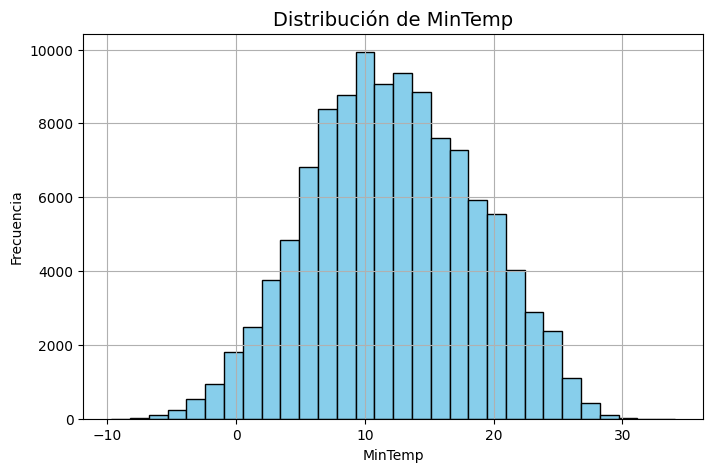

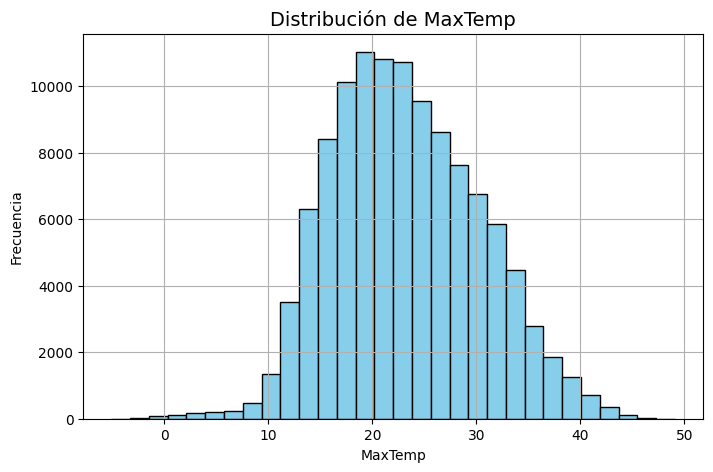

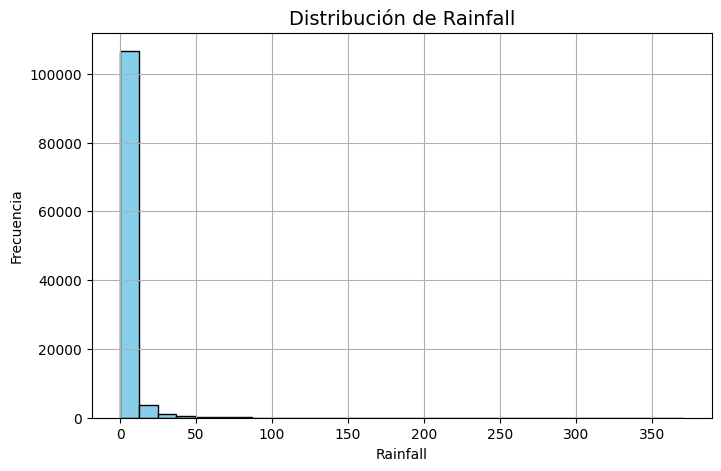

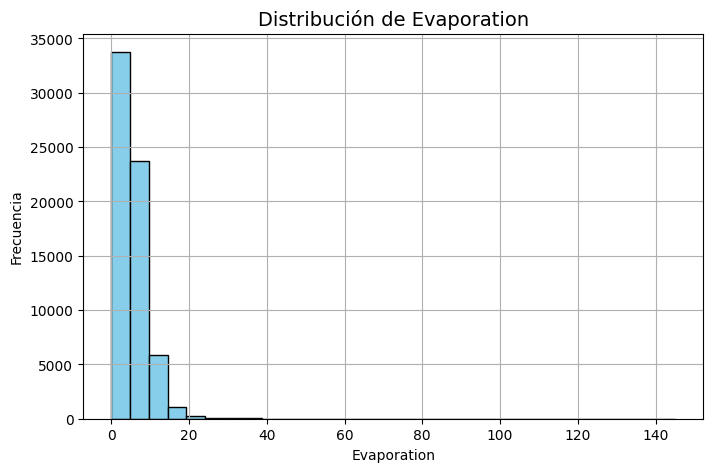

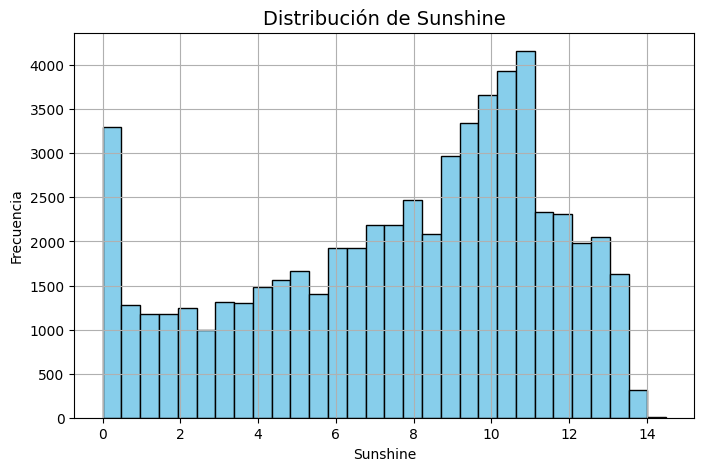

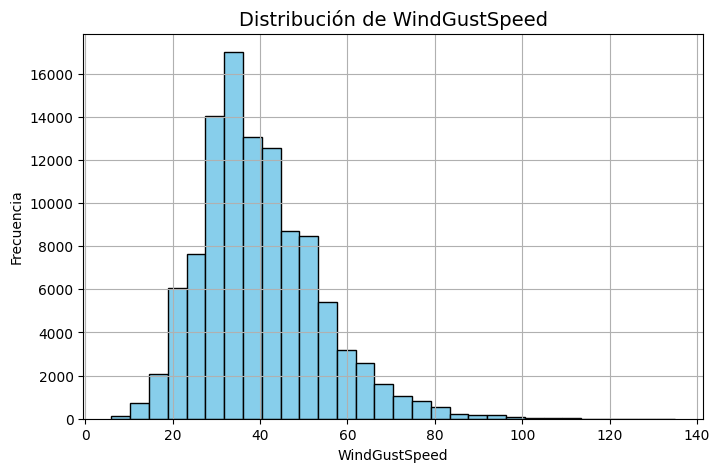

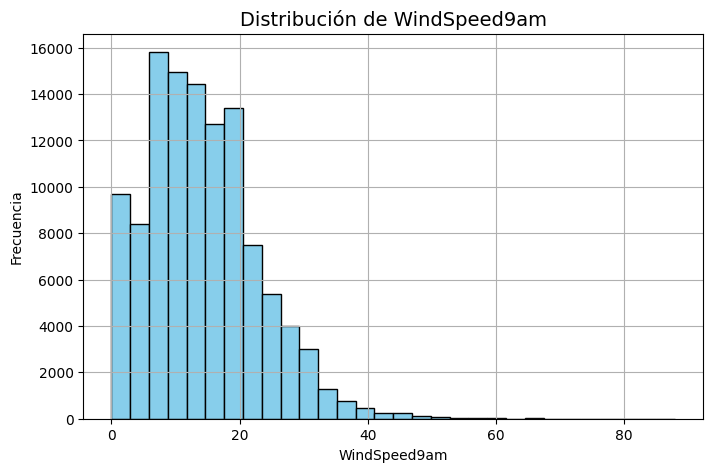

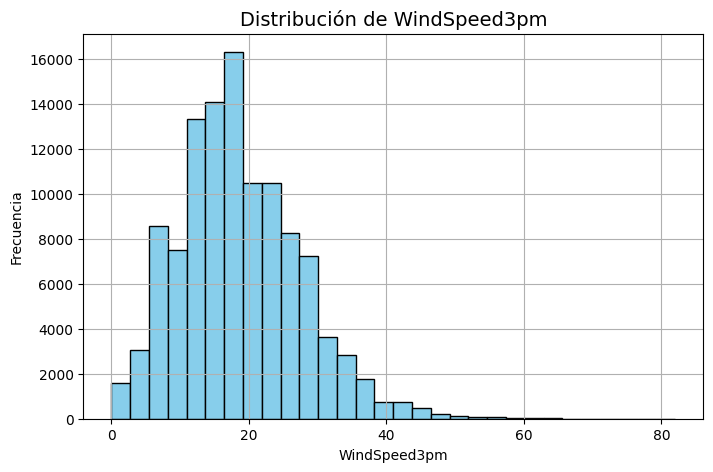

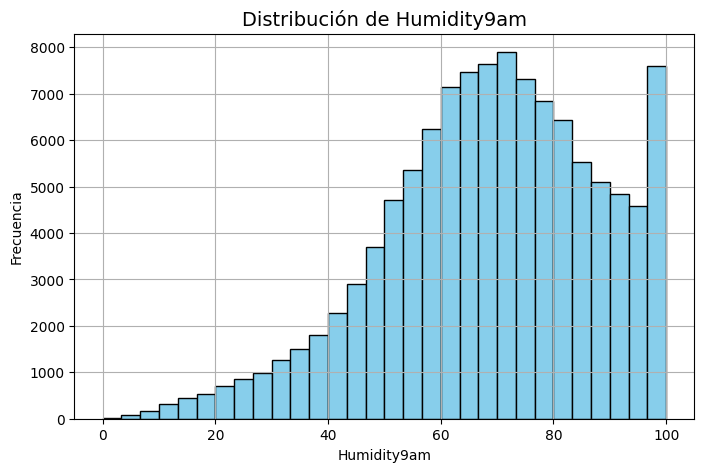

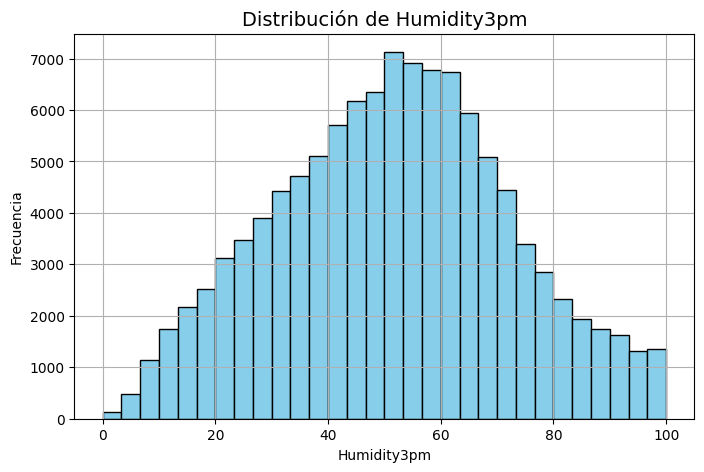

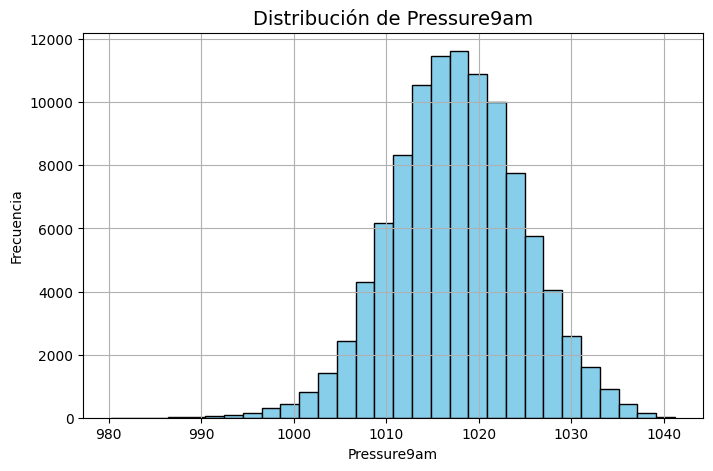

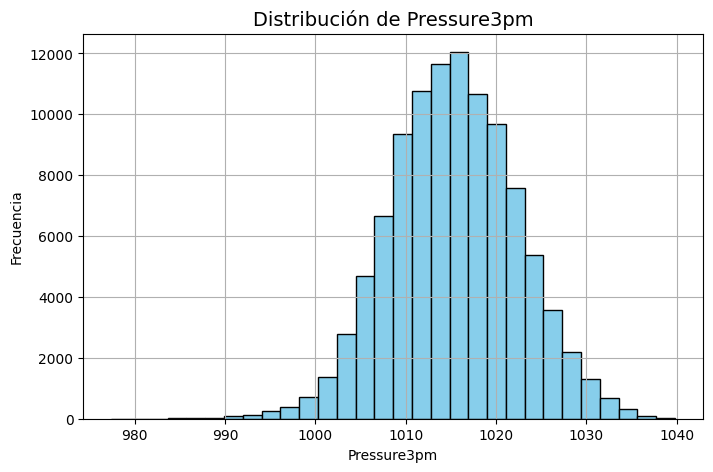

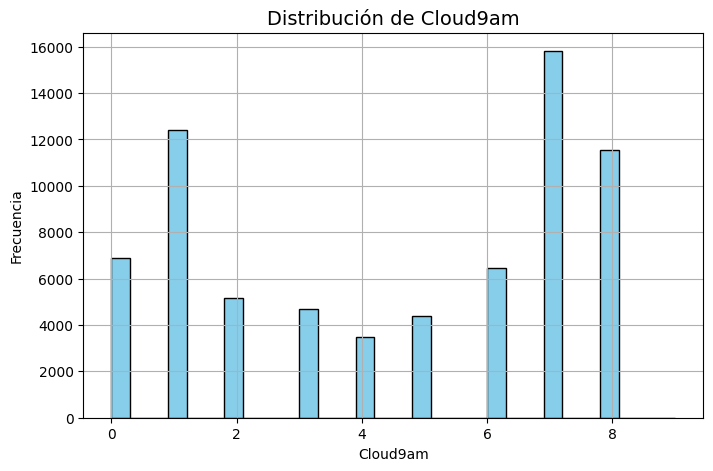

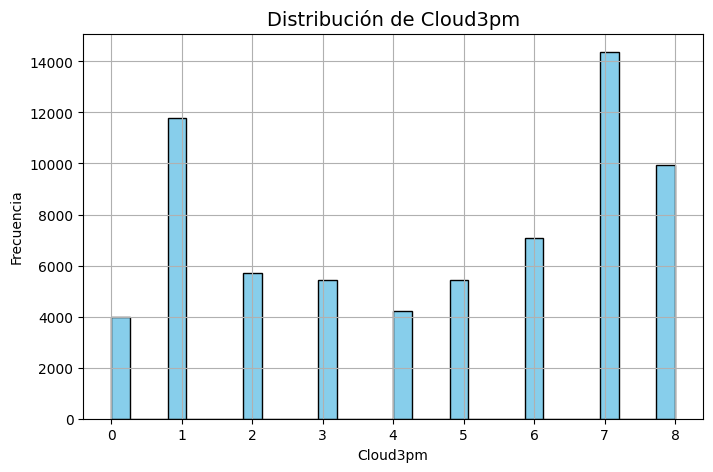

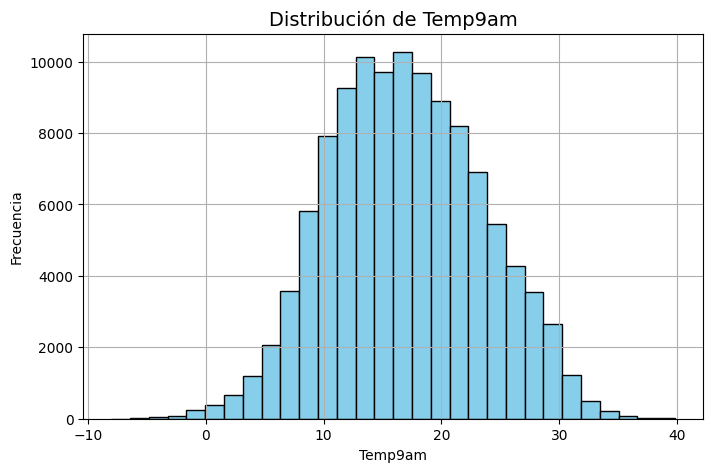

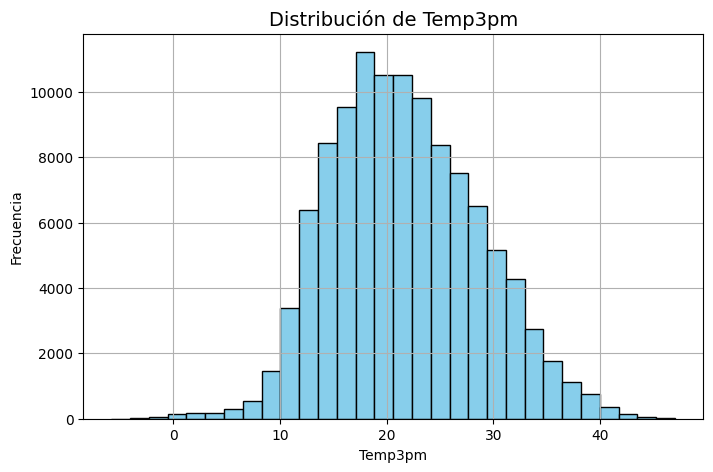

In [18]:
import matplotlib.pyplot as plt

# Hacemos un for para graficar variable por variable
for col in cols_num:
    plt.figure(figsize=(8, 5))
    X_train[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribución de {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

En las distribuciones de las variables numéricas se observan distribuciones simétricas en la mayoría de los casos, excepto en las variables 'Rainfall' y 'Evaporation', donde se ve una asimetría hacia la derecha.

---
#### Variables Categóricas

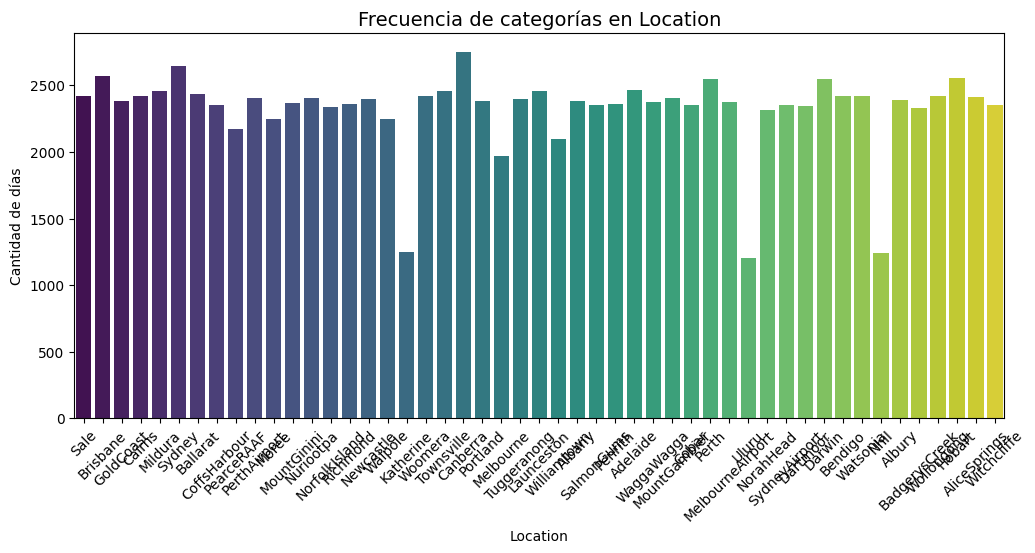

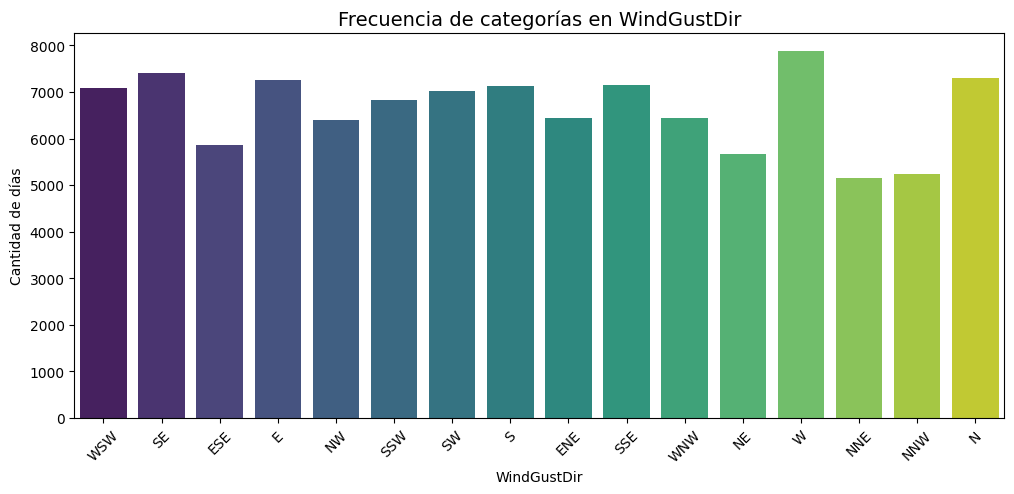

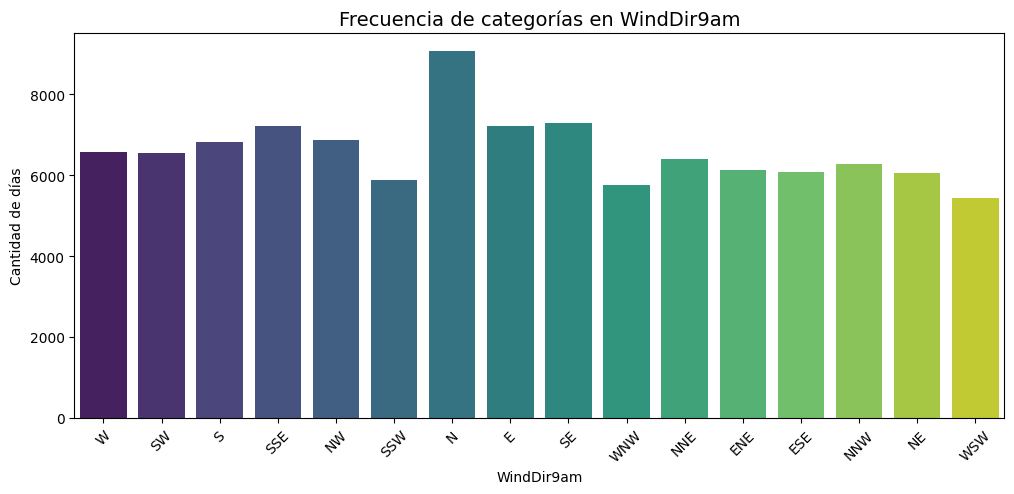

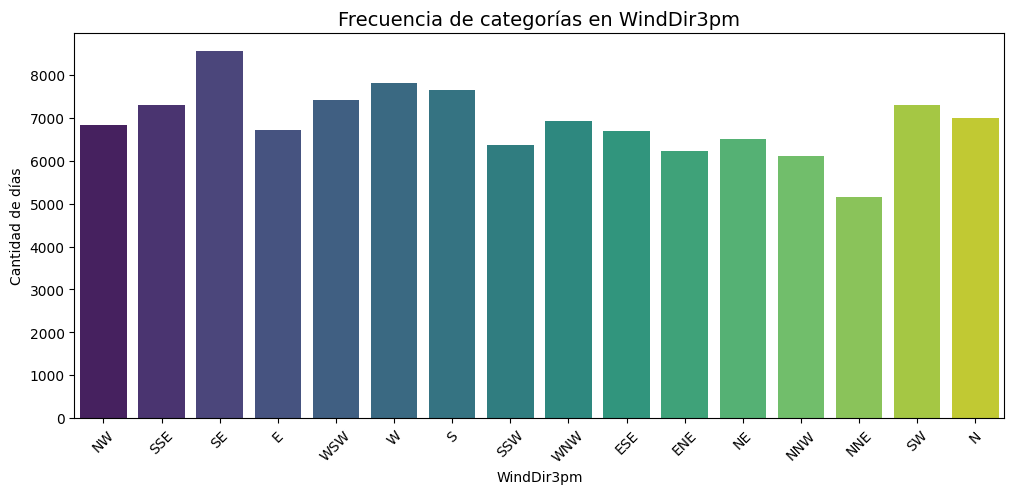

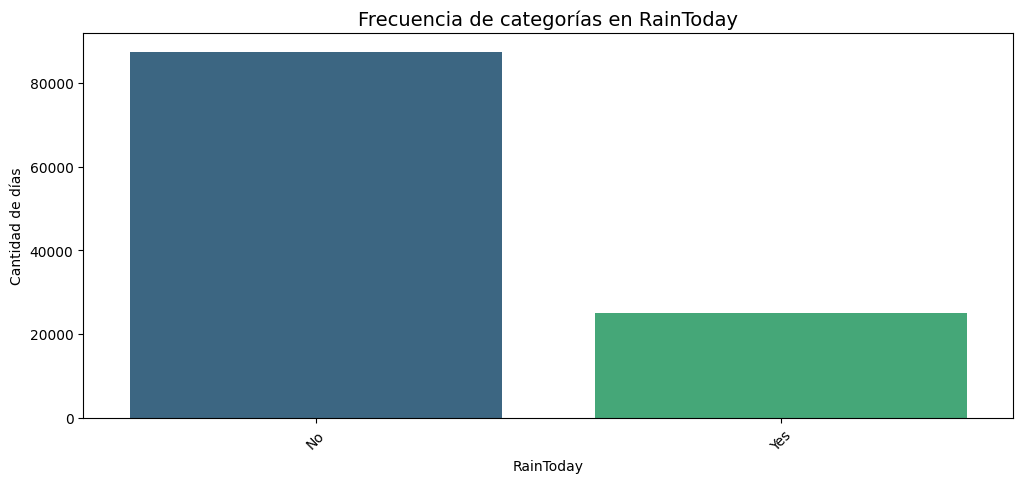

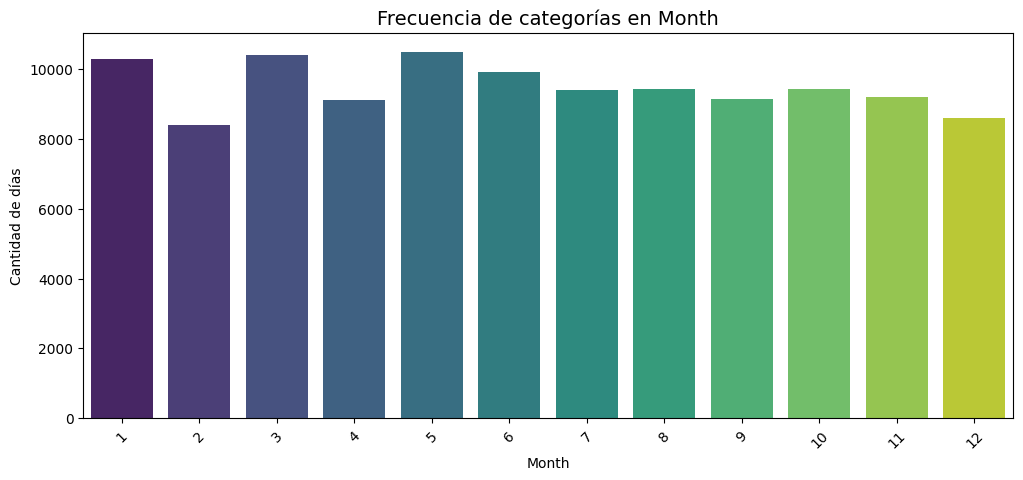

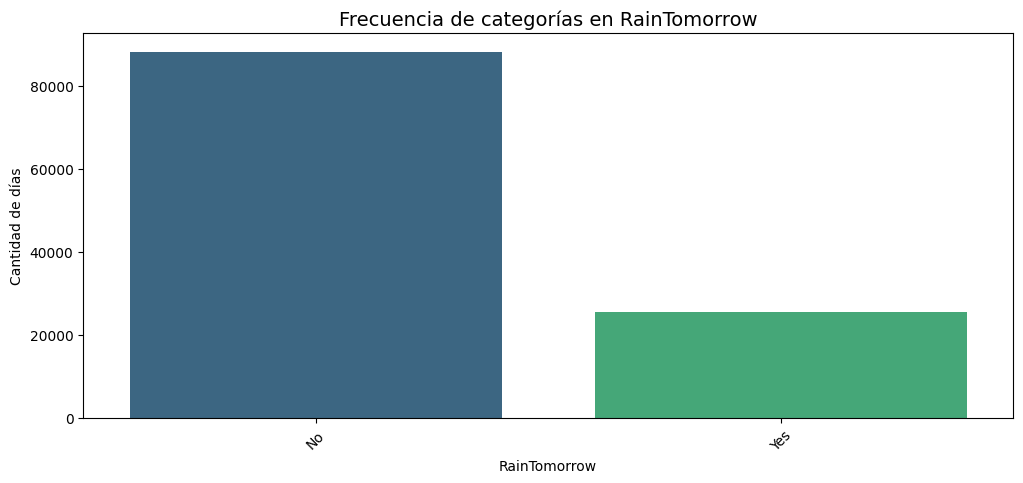

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_cat_target = cols_cat + target

# 2. Hacemos un for para graficar barras
for col in cols_cat_target:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df_train, x=col, palette='viridis')
    plt.title(f'Frecuencia de categorías en {col}', fontsize=14)
    plt.xticks(rotation=45)
    plt.ylabel('Cantidad de días')
    plt.show()

Se observa que variables como Location o WindDir tienen alta cardinalidad. Al observar la distribución de RainTomorrow se concluye que el dataset está fuertemente desbalanceado. Creemos que es importante saber esto ya que el desbalanceo afecta al modelo y en caso de estarlo probablemente se deba hacer un paso extra para balancear las clases.

---
### Limpieza el Dataset

---
#### Imputación

In [20]:
# Para los números usamos la mediana (menos sensible a outliers)
imputer_num = SimpleImputer(strategy='median')
# Para los textos usamos la moda (el valor que más se repite)
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit_transform: aprende la mediana del train y rellena el train
X_train[cols_num] = imputer_num.fit_transform(X_train[cols_num])
# Transform: rellena el test con la misma mediana que aprendió del train
X_test[cols_num] = imputer_num.transform(X_test[cols_num])

# Rellenamos las categóricas
X_train[cols_cat] = imputer_cat.fit_transform(X_train[cols_cat])
X_test[cols_cat] = imputer_cat.transform(X_test[cols_cat])

# Chequeo de seguridad: tiene que dar 0 y 0
print("NaNs restantes en X_train:", X_train.isna().sum().sum())
print("NaNs restantes en X_test:", X_test.isna().sum().sum())


NaNs restantes en X_train: 0
NaNs restantes en X_test: 0


Para imputar los valores nulos, se utiliza la mediana de las variables numéricas (menos sensible a outliers que la media). Y se utiliza la categoría más frecuente para imputar los nulos de las variables categóricas.
En ambos casos, se usa fit transform para el conjunto train, pero solo transform para el conjunto test, esto para que el test se impute con los valores calculados en train, y así evitar fuga de datos.

---
### Codificación de Variables Categóricas

In [21]:


# --- CODIFICACIÓN (One-Hot Encoding) ---
# Lo aplicamos al dataset antes del escalado.
X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

# Aseguramos que X_train y X_test tengan las mismas columnas (por si en Test falta alguna ciudad que estaba en Train)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Pasamos la target a 1 y 0
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

print(f'Dimensiones de X_Train: {X_train.shape}')
print(f'Dimensiones de X_Test: {X_test.shape}')

Dimensiones de X_Train: (113722, 121)
Dimensiones de X_Test: (28431, 121)


---
### Matriz de Correlación

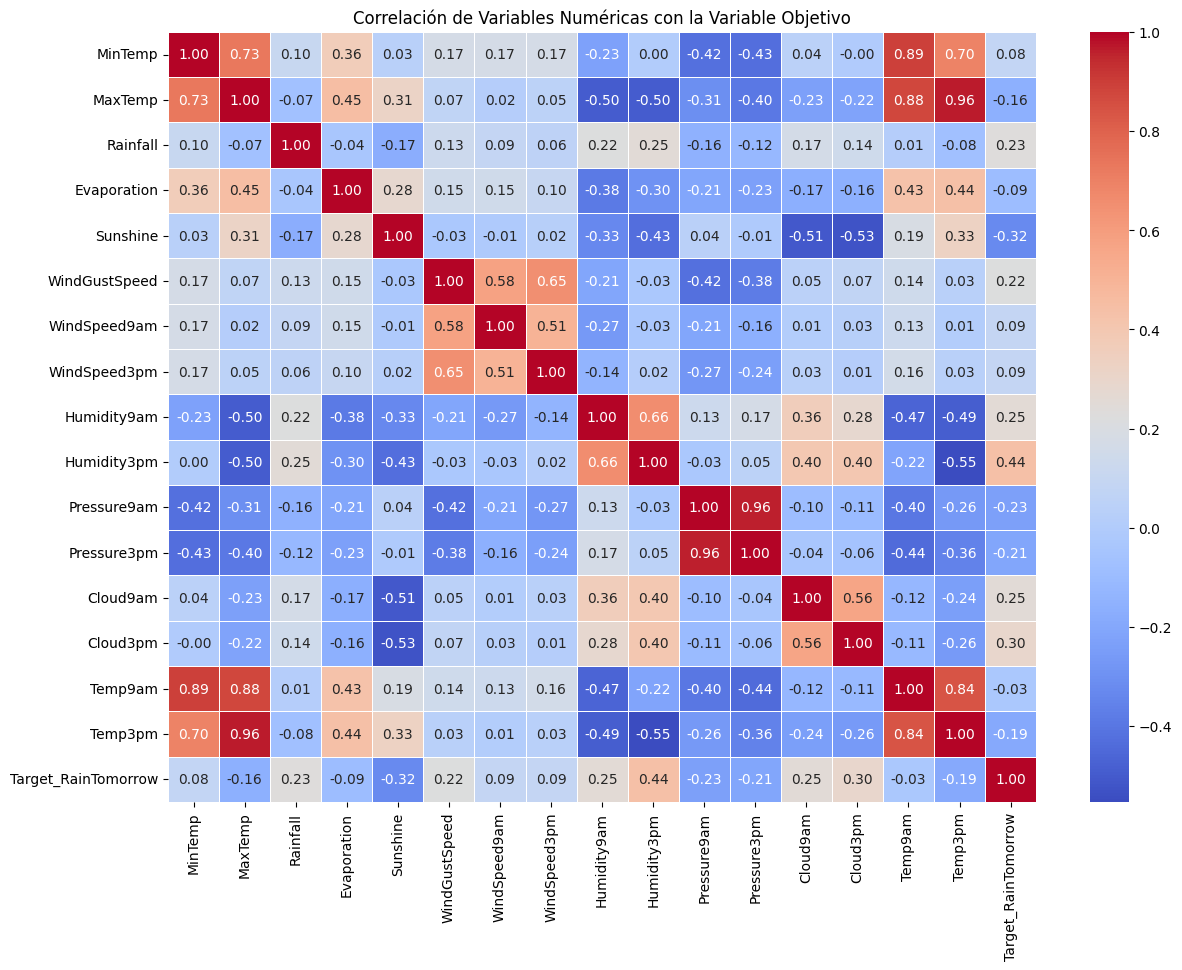

In [22]:
# --- MATRIZ DE CORRELACIÓN (Incluyendo la Variable Objetivo) ---
plt.figure(figsize=(14, 10))

# Unimos temporalmente las numéricas con la target para el gráfico
# Usamos y_train que ya mapeamos a 1 y 0
df_corr = X_train[cols_num].copy()
df_corr['Target_RainTomorrow'] = y_train

# Graficamos
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlación de Variables Numéricas con la Variable Objetivo")
plt.show()

En la matriz de correlación se observan algunos aspectos:

La variable objetivo tiene mayor correlación positiva con Humidity3pm y Cloud3pm. Por el contrario muestra correlación negativa con Sunshine. Esto indica que la humedad y la ausencia de sol son los principales precursores de lluvia para el día siguiente.

Por otro lado se detecta Multicolinealidad, dada la alta correlación entre variables explicativas como MinTemp y Temp9am, MaxTemp y Temp3pm, Pressure9am y Pressure3pm. Esto sugiere redundancia en los datos, pero al no querer identificar las variables que más explican la variable objetivo, se decide no removerlas.

---
### Escalado

In [23]:


# Creamos el escalador
scaler = StandardScaler()

# Entrenamos y transformamos el Train (solo las numéricas)
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])

# Transformamos el Test con lo aprendido del Train
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Chequeo final de seguridad
print("Media de MinTemp en Train (debe ser aprox 0):", round(X_train['MinTemp'].mean(), 2))
print("Desviación estándar de MinTemp en Train (debe ser 1):", round(X_train['MinTemp'].std(), 2))

Media de MinTemp en Train (debe ser aprox 0): 0.0
Desviación estándar de MinTemp en Train (debe ser 1): 1.0


---
## Clasificación con Regresión Logística

---
### Sin Balancear

---
#### Entrenamiento del Modelo

In [24]:
# Creación del modelo
model = LogisticRegression(random_state=42)

# Entrenamiento del modelo
model.fit(X_train, y_train)

LogisticRegression(random_state=42)

---
#### Test

In [25]:
# Predicción en conjunto test
y_pred = model.predict(X_test)

---
#### Métricas

In [26]:
# Cálculo de las métricas del modelo

accuracy_logreg = accuracy_score(y_test, y_pred)

confusion_matrix_logreg = confusion_matrix(y_test, y_pred)

classification_report_logreg = classification_report(y_test, y_pred)

# Imprimir métricas

print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg)

Métricas para logreg:
Exactitud: 0.8468573036474271
--------------------
Matriz de confusión:
[[20839  1218]
 [ 3136  3238]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     22057
           1       0.73      0.51      0.60      6374

    accuracy                           0.85     28431
   macro avg       0.80      0.73      0.75     28431
weighted avg       0.84      0.85      0.84     28431



Tras obtener las métricas, se observa una exactitud (accuracy) del 85%. Si bien este número parece muy alto, el análisis detallado por categorías revela que el modelo está fuertemente influenciado por el desbalanceo de los datos (hay muchos más días sin lluvia que con lluvia en el dataset).

El modelo es excelente para predecir los días en los que no llueve (clase 0), con un recall de 0.94. Esto infla la exactitud general del modelo.

Para la clase "Sí llueve" (clase 1), el recall baja a 0.51. Esto significa que el modelo solo logra detectar la mitad de las lluvias reales.

Falsos negativos significa que el modelo predijo que no iba a llover y llovió, mientras que falsos positivos significa que el modelo predijo que llovería y no llovió.

---
#### Curvas ROC-AOC

In [27]:
# Obtengo las probabilidades de predicción del modelo
y_probs = model.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

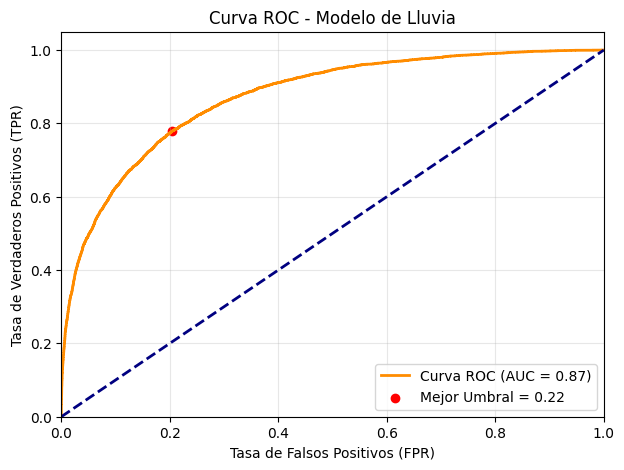

El Área bajo la Curva (AUC) es: 0.8710
El mejor umbral calculado es: 0.2196


In [28]:
# Cálculo del Mejor Umbral
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo = np.argmax(tpr - fpr)
mejor_umbral = thresholds[idx_optimo]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr[idx_optimo], tpr[idx_optimo], color='red', label='Mejor Umbral = %0.2f' % mejor_umbral)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral:.4f}")

El modelo alcanzó un AUC de 0.87, lo que confirma una excelente capacidad discriminatoria para distinguir entre días lluviosos y secos.
A partir de maximizar la diferencia entre TPR y FPR, se determinó que el umbral óptimo es 0.22. Mientras que el umbral estándar de 0.5 penalizaba el Recall (0.51) generando muchos Falsos Negativos, este nuevo umbral sugiere que bajar la vara de decisión permite capturar una mayor cantidad de días de lluvia, logrando un modelo mucho más sensible y útil para la prevención climática.

Consideramos que se ha logrado un buen fitting. El modelo no presenta overfitting, ya que mantiene un alto desempeño (AUC 0.87) sobre el conjunto de test, demostrando capacidad de generalización. La diferencia en las métricas de cada clase no se debe a un mal ajuste, sino al desbalanceo del dataset.

---
### Dataset Balanceado

---
#### Entrenamiento del Modelo

In [29]:
model_balanced = LogisticRegression(class_weight='balanced', random_state=42)

model_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

---
#### Test

In [30]:
y_pred_balanced = model_balanced.predict(X_test)

---
#### Métricas

In [31]:
accuracy_logreg_b = accuracy_score(y_test, y_pred_balanced)

confusion_matrix_logreg_b = confusion_matrix(y_test, y_pred_balanced)

classification_report_logreg_b = classification_report(y_test, y_pred_balanced)

# Imprimir métricas
print("Métricas para logreg:")
print(f'Exactitud: {accuracy_logreg_b}')
print('-'*20)
print("Matriz de confusión:")
print(confusion_matrix_logreg_b)
print('-'*20)
print("Reporte de clasificación:")
print(classification_report_logreg_b)

Métricas para logreg:
Exactitud: 0.7925503851429777
--------------------
Matriz de confusión:
[[17627  4430]
 [ 1468  4906]]
--------------------
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86     22057
           1       0.53      0.77      0.62      6374

    accuracy                           0.79     28431
   macro avg       0.72      0.78      0.74     28431
weighted avg       0.83      0.79      0.80     28431



|Métrica | Modelo Original (0.5) | Modelo Balanceado|
|--------|-----------------------|------------------|
|Accuracy | 85% | 79%|
|Recall (Lluvia) | 51% | 77%|
|Falsos Negativos | 3.136 | 1.468|

Aunque la exactitud bajó un poco, el modelo balanceado es mucho mejor porque detecta casi el 80% de las lluvias. Redujimos a la mitad los Falsos Negativos. Si bien disminuyó la precisión para los días de lluvia, es preferible predecir que llueve y que no se cumpla, a que se dé la situación inversa.

---
#### Curva ROC-AUC

In [32]:
# Obtengo las probabilidades de predicción del modelo
y_probs_b = model_balanced.predict_proba(X_test)[:, 1]

# Calculo la ROC y el AUC
fpr_b, tpr_b, thresholds_b = roc_curve(y_test, y_probs_b)
roc_auc_b = auc(fpr_b, tpr_b)

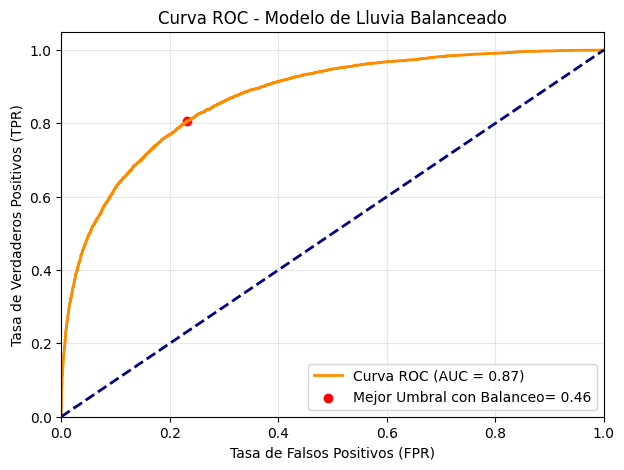

El Área bajo la Curva (AUC) es: 0.8715
El mejor umbral calculado es: 0.4550


In [33]:
# Cálculo del Mejor Umbral
# Buscamos el punto donde la diferencia entre TPR y FPR es máxima
idx_optimo_b = np.argmax(tpr_b - fpr_b)
mejor_umbral_b = thresholds_b[idx_optimo_b]

# Graficamos la curva ROC (usando el estilo de tu clase)
plt.figure(figsize=(7, 5))
plt.plot(fpr_b, tpr_b, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc_b)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# Marcamos el punto del mejor umbral
plt.scatter(fpr_b[idx_optimo_b], tpr_b[idx_optimo_b], color='red', label='Mejor Umbral con Balanceo= %0.2f' % mejor_umbral_b)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo de Lluvia Balanceado')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El Área bajo la Curva (AUC) es: {roc_auc_b:.4f}")
print(f"El mejor umbral calculado es: {mejor_umbral_b:.4f}")

Al entrenar el modelo con balanceo, el umbral óptimo se desplazó hacia 0.46,
acercándose al umbral estándar de 0.50. Esto demuestra que el modelo ya está
compensando internamente el desbalanceo de los datos, logrando un mejor equilibrio
entre sensibilidad y especificidad sin necesidad de forzar umbrales externos tan
bajos como en el caso sin balanceo (0.22).

Consideramos que se ha logrado un buen fitting también en este caso por el valor alto de AUC, y también se mejora el recall para la clase 1 (lluvia), debido al balanceo.

---
## Modelo Base

In [34]:
# Buscamos la clase mayoritaria

clase_mayoritaria = y_train.value_counts().idxmax()
print(f"La clase mayoritaria identificada es: {clase_mayoritaria} (No llueve)")

# 2. Implementamos el modelo base: clasificar todos los ejemplos en esa clase

y_pred_base = np.full(shape=y_test.shape, fill_value=clase_mayoritaria)

print("Métricas del Modelo Base (Criterio: Clase Mayoritaria):")
print(classification_report(y_test, y_pred_base, zero_division=0))

La clase mayoritaria identificada es: 0 (No llueve)
Métricas del Modelo Base (Criterio: Clase Mayoritaria):
              precision    recall  f1-score   support

           0       0.78      1.00      0.87     22057
           1       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431



A través de este análisis, se demuestra que un buen accuracy no garantiza un modelo de calidad. Es fundamental evaluar métricas adicionales como el Recall y el F1-Score para entender el desempeño sobre ambas clases por igual.

Asimismo, para la comparación de modelos se basó en el costo de los errores: en un contexto meteorológico, el impacto de un Falso Negativo (no avisar de una lluvia real) es mucho mayor que el de un Falso Positivo (dar una falsa alarma). Por lo tanto, el modelo de Regresión Logística con balanceo, al priorizar la sensibilidad para detectar tormentas, resulta ser la solución más robusta y útil para el problema planteado.

## Optimización de Hiperparámetros con Optuna

Para optimizar los hiperparámetros de los modelos se eligió **Optuna** por sobre las alternativas disponibles:

- **Grid Search** fue descartado porque prueba todas las combinaciones posibles de una grilla definida, lo que resulta computacionalmente muy costoso cuando el espacio de búsqueda es amplio.
- **Random Search** fue descartado porque, si bien es más rápido, prueba combinaciones al azar sin aprender de los intentos anteriores, lo que lo hace ineficiente.
- **Optuna** utiliza el algoritmo TPE (Tree-structured Parzen Estimator), una estrategia bayesiana que aprende de cada intento para dirigir la búsqueda hacia regiones más prometedoras. Esto lo hace más eficiente en tiempo y calidad de resultados.


In [35]:
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Silenciamos los logs de Optuna para que no llene la pantalla
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [36]:

def train_evaluate_model(modelo, params, X_train, y_train, X_test, y_test):
    modelo.set_params(**params)
    modelo.fit(X_train, y_train)
    
    y_probs = modelo.predict_proba(X_test)[:, 1]
    score = roc_auc_score(y_test, y_probs)
    return score

def objective_logreg(trial):
    C = trial.suggest_float('C', 0.001, 10)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'C': C,
        'max_iter': max_iter

    }

    return train_evaluate_model(model_balanced, params, X_train, y_train, X_test, y_test)
motor_congelado = TPESampler(seed=42)

study_logreg = optuna.create_study(direction='maximize', sampler=motor_congelado)
study_logreg.optimize(objective_logreg, n_trials=10)
best_logreg_params = study_logreg.best_params
print("Mejores parámetros:", best_logreg_params)

Mejores parámetros: {'C': 8.324593965363416, 'max_iter': 291}


In [37]:
model_balanced.set_params(**best_logreg_params)
model_balanced.fit(X_train, y_train)
logreg_auc = roc_auc_score(y_test, model_balanced.predict_proba(X_test)[:, 1])
print("AUC Modelo Optimizado:", logreg_auc)

AUC Modelo Optimizado: 0.8714902935898218


In [38]:
print("AUC Modelo Original:", roc_auc_b)
print("AUC Modelo Optimizado con Optuna:", logreg_auc)

AUC Modelo Original: 0.8714792900654079
AUC Modelo Optimizado con Optuna: 0.8714902935898218


Tras aplicar Optuna con 10 trials, los mejores hiperparámetros encontrados fueron
C = 8.32 y max_iter = 291. Sin embargo, al comparar el AUC del modelo original
(0.8715) con el del modelo optimizado (0.8715), se observa que la mejora es
prácticamente nula.

Esto no es un resultado negativo. La Regresión Logística es un modelo relativamente
simple que no depende fuertemente de sus hiperparámetros, especialmente cuando el
preprocesamiento fue bien realizado (imputación, escalado, balanceo de clases).
En este caso, el modelo ya estaba bien configurado con los valores por defecto,
y la principal mejora en el desempeño se había logrado en pasos anteriores
mediante el uso de class_weight='balanced'.

Concluimos que la optimización de hiperparámetros es más determinante en modelos
más complejos donde el espacio de búsqueda es mayor
y los hiperparámetros tienen un impacto más significativo en el resultado.

---
## Explicabilidad con SHAP

In [39]:
import shap

# Inicializamos el visualizador de SHAP
shap.initjs()

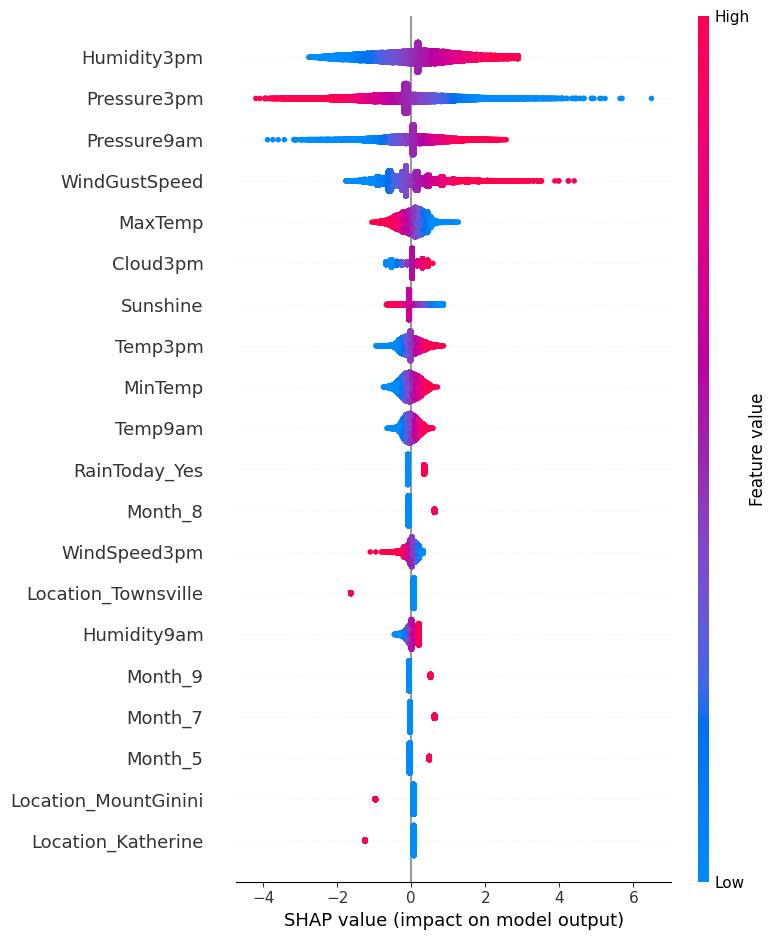

In [40]:
import numpy as np

X_train_array = np.array(X_train, dtype=np.float64)
X_test_array = np.array(X_test, dtype=np.float64)

explainer = shap.LinearExplainer(model_balanced, X_train_array)
shap_values = explainer(X_test_array)

shap.summary_plot(shap_values.values, X_test_array, feature_names=X_test.columns.tolist())

LinearExplainer: es el explainer específico para modelos lineales como Regresión Logística. Es más eficiente que el explainer genérico porque aprovecha la estructura lineal del modelo.
explainer(X_test): calcula los valores SHAP para cada observación del test. Básicamente, para cada fila y cada variable, calcula cuánto contribuyó esa variable a la predicción.

### Gráfica Global 1: Summary Plot

A partir del summary plot de SHAP se observan claramente las características que más impactan en las decisiones de la regresión logística y en qué dirección lo hacen. 
Entre las variables más determinantes se encuentran *Humidity3pm* y *WindGustSpeed*. En ambos casos existe una correlación directa fuerte, los valores altos de estas variables (puntos rojos) empujan la predicción del modelo hacia la derecha, aumentando significativamente la probabilidad de lluvia para el día siguiente.

Por otro lado, variables como la presión atmosférica a las 3 PM (*Pressure3pm*) y la cantidad de horas de sol (*Sunshine*) presentan una relación inversa. Los días con baja presión atmosférica o poca luz solar (puntos azules) son los que el modelo asocia con una mayor probabilidad de lluvia. Esta interpretación confirma que el algoritmo ha logrado capturar con éxito la dinámica meteorológica real esperada.

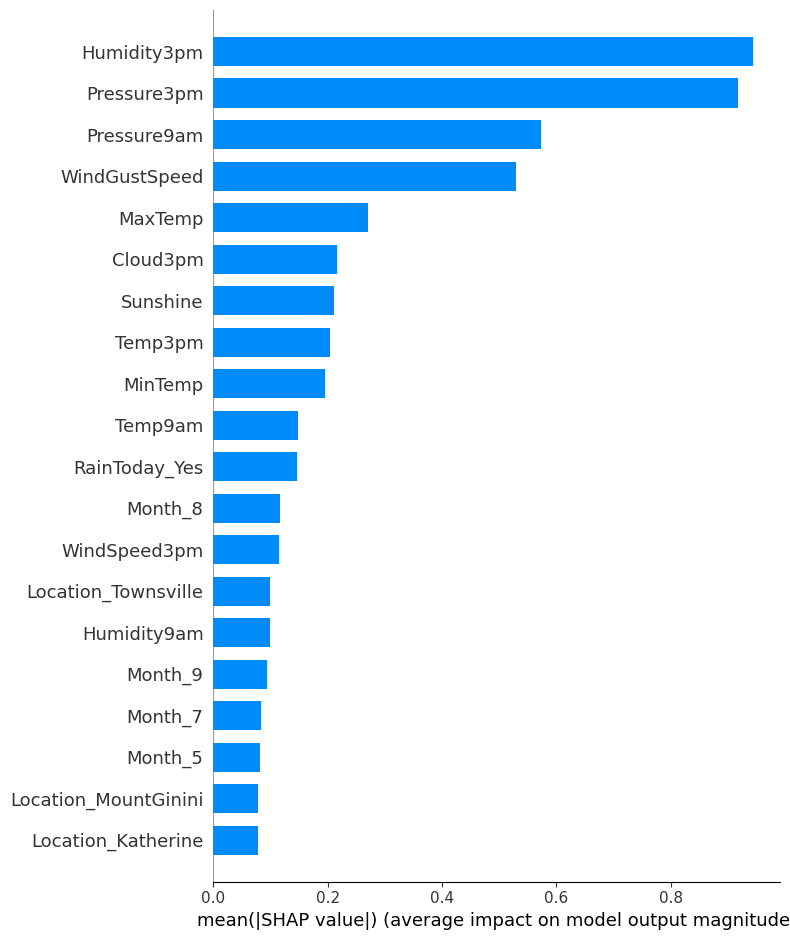

In [41]:
# Gráfica Global 2: Bar Plot
shap.summary_plot(shap_values.values, X_test_array, feature_names=X_test.columns.tolist(), plot_type="bar")

### Gráfica Global 2: Bar Plot

El bar plot muestra el promedio del valor absoluto de SHAP para cada variable,
es decir, su importancia global en el modelo sin distinguir dirección.

Se confirma lo observado en el summary plot:
- **Humidity3pm** y **Pressure3pm** son las dos variables más importantes por amplia
  diferencia, con un impacto promedio de casi 1 punto en el output del modelo.
- **Pressure9am** y **WindGustSpeed** ocupan el tercer y cuarto lugar.
- Las variables de temperatura (MaxTemp, Temp3pm, MinTemp, Temp9am) tienen una
  importancia media similar entre sí.
- Las variables menos importantes son las de ubicación (Location_MountGinini,
  Location_Katherine) y los meses, lo que sugiere que la lluvia en Australia
  depende más de las condiciones meteorológicas del día que de la época del año
  o la ubicación geográfica.

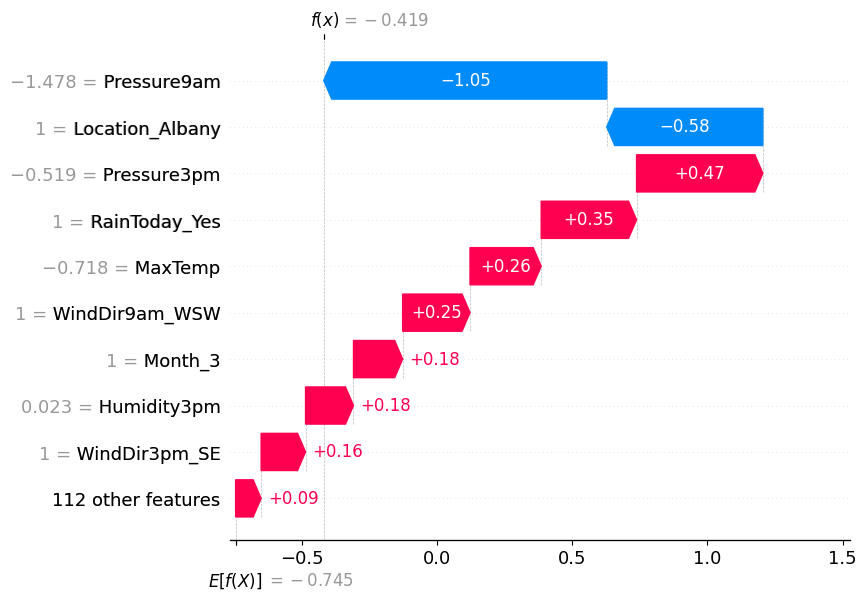

In [42]:
explainer = shap.LinearExplainer(model_balanced, X_train_array, feature_names=X_test.columns.tolist())
shap_values = explainer(X_test_array)
# Gráfica Local 1: Waterfall Plot - un caso donde predijo lluvia
idx_lluvia = np.where(y_test.values == 1)[0][0]
shap.waterfall_plot(shap_values[idx_lluvia])

### Gráfica Local 1: Waterfall Plot - Caso donde llovió

El gráfico de cascada (waterfall plot) permite desglosar la toma de decisión del algoritmo para una instancia individual (un solo día). 

Parte de un valor base o promedio esperado (E[f(x)] = -0.744) y muestra cómo el valor específico de cada variable meteorológica suma (barras rojas hacia la derecha) o resta (barras azules hacia la izquierda) a la probabilidad, construyendo el camino hasta alcanzar la predicción final (f(x) = -0.419).

En este caso particular se observa que la baja presión a las 9 am tiraba la predicción para la izquierda, pero la suma de otras variables como la presión a las 3 pm, que había llovido ese día y la temperatura máxima, empujaron a predecir lluvia para el día siguiente.



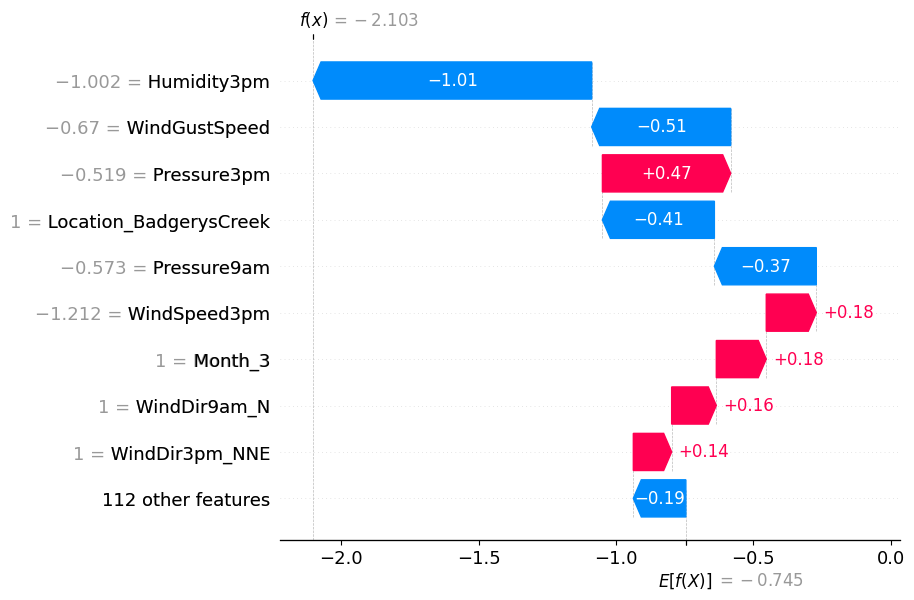

In [43]:
# Gráfica Local 2: Waterfall Plot - un caso donde predijo que no llueve
idx_no_lluvia = np.where(y_test.values == 0)[0][0]
shap.waterfall_plot(shap_values[idx_no_lluvia])

### Gráfica Local 2: Waterfall Plot - Caso donde no llovió

En este caso el modelo predijo correctamente que no llovería, con una predicción
final de f(x) = -2.11, muy por debajo del valor base E[f(X)] = -0.744.

Se observa que:
- **Humidity3pm = -1.002** fue la variable más influyente (-1.01), reduciendo
  fuertemente la probabilidad de lluvia. Una humedad baja a la tarde es un
  indicador claro de día seco.
- **WindGustSpeed = -0.67** también contribuyó negativamente (-0.5), indicando
  que vientos moderados no favorecen la lluvia.
- **Location_BadgerysCreek** y **Pressure9am** también empujaron la predicción
  hacia no lluvia.
- **Pressure3pm** (+0.47) y **WindSpeed3pm** (+0.18) intentaron empujar hacia
  lluvia pero no fueron suficientes para revertir la predicción.

En este caso el modelo acertó: la baja humedad de la tarde y la velocidad del
viento fueron suficientes para predecir correctamente un día sin lluvia.
Esto refuerza lo observado globalmente: **Humidity3pm** es la variable
más determinante del modelo.

---
## AutoML

In [44]:
from pycaret.classification import *
from sklearn.datasets import fetch_california_housing
import pandas as pd
from sklearn.model_selection import train_test_split

In [45]:
# Armamos el dataframe con los datos ya procesados
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

In [46]:
# Inicializamos el entorno de PyCaret para un problema de clasificación
clf = setup(data=train_df, target='RainTomorrow', session_id=42)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Original data shape,"(113722, 122)"
4,Transformed data shape,"(113722, 122)"
5,Transformed train set shape,"(79605, 122)"
6,Transformed test set shape,"(34117, 122)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,simple


In [47]:
# Comparamos todos los modelos disponibles y obtenemos el mejor
best_model = compare_models()
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8568,0.8855,0.5407,0.7510,0.6287,0.5429,0.5542,1.1400
rf,Random Forest Classifier,0.8538,0.8807,0.4970,0.7696,0.6039,0.5193,0.5380,6.1130
et,Extra Trees Classifier,0.8529,0.8817,0.4780,0.7812,0.5930,0.5095,0.5325,16.7650
gbc,Gradient Boosting Classifier,0.8498,0.8725,0.5022,0.7449,0.5999,0.5117,0.5268,9.7360
lr,Logistic Regression,0.8491,0.8700,0.5170,0.7313,0.6057,0.5158,0.5277,2.2920
lda,Linear Discriminant Analysis,0.8470,0.8672,0.5232,0.7180,0.6053,0.5133,0.5232,1.6770
ridge,Ridge Classifier,0.8459,0.8672,0.4610,0.7565,0.5728,0.4855,0.5077,0.1810
svm,SVM - Linear Kernel,0.8445,0.8618,0.5020,0.7243,0.5897,0.4982,0.5126,0.3570
ada,Ada Boost Classifier,0.8440,0.8624,0.5010,0.7179,0.5901,0.4975,0.5098,1.5790
knn,K Neighbors Classifier,0.8384,0.8227,0.4861,0.7018,0.5743,0.4786,0.4909,6.8990


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [48]:
# Hacemos predicciones sobre el conjunto de test
predictions = predict_model(best_model, data=test_df, raw_score=True)
print(predictions.head())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8557,0.8850,0.5339,0.7502,0.6238,0.5376,0.5495


         MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
3114   -0.354516  0.405485 -0.273645    -0.119106  0.166339      -0.670072   
120716 -0.666419 -0.380628 -0.250249    -0.119106  1.212961      -0.745908   
62856  -0.744395 -0.338514 -0.273645     0.130904  1.790407       0.088281   
66599  -0.027017 -0.184099 -0.273645     0.318410 -0.086294       0.164117   
111484  0.269292 -0.717533  0.170885    -0.119106  0.166339      -0.139225   

        WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  ...  Month_7  \
3114       -1.579922     -1.211504    -0.293400    -1.002283  ...    False   
120716     -0.903218     -0.184726    -0.124799    -0.312042  ...    False   
62856      -0.790434      1.526571     0.633903    -0.127330  ...    False   
66599       0.224623      1.412484     0.444227    -0.185660  ...    False   
111484      0.675759     -0.070640     0.128101     0.023356  ...    False   

        Month_8  Month_9  Month_10  Month_11  Month_12  RainTo

In [49]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

y_test_labels = test_df['RainTomorrow']
y_pred_labels = predictions['prediction_label']
y_pred_proba = predictions['prediction_score_1'] 

print("Accuracy:", round(accuracy_score(y_test_labels, y_pred_labels), 4))
print("AUC:", round(roc_auc_score(y_test_labels, y_pred_proba), 4))
print("F1:", round(f1_score(y_test_labels, y_pred_labels), 4))

Accuracy: 0.8557
AUC: 0.885
F1: 0.6238


Tras evaluar diversos algoritmos, el mejor resultado obtenido fue con LightGBM, destacándose tanto por su eficiencia al entrenar como por sus métricas generales. Lo más importante es que el modelo demuestra una excelente capacidad de generalización con datos nuevos, lo que nos permite descartar problemas de sobreajuste. Al evaluarlo sobre el conjunto de testeo, la exactitud (Accuracy) se mantuvo sumamente estable en un 85.5%, un valor prácticamente idéntico al conseguido en la etapa de validación.

De todas formas, al observar el F1-Score (cercano al 62%), se hace evidente que trabajamos con un conjunto de datos desbalanceado. Al existir una mayor proporción de días secos, al modelo le resulta más sencillo clasificar correctamente estos casos, presentando un mayor desafío a la hora de identificar todos los días de tormenta. A pesar de esta limitación propia de los datos, el valor de AUC obtenido (aproximadamente 0.88) nos confirma que el modelo aprendió efectivamente a discriminar entre ambas clases y no se está limitando a predecir únicamente la clase mayoritaria.

En definitiva, logramos desarrollar un modelo predictivo sólido y confiable para esta problemática. Como trabajo a futuro, y en caso de requerir identificar una mayor cantidad de días lluviosos, podríamos explorar la implementación de técnicas de balanceo de datos desde el preprocesamiento. No obstante, para los objetivos de este análisis, los resultados finales obtenidos son sumamente satisfactorios.